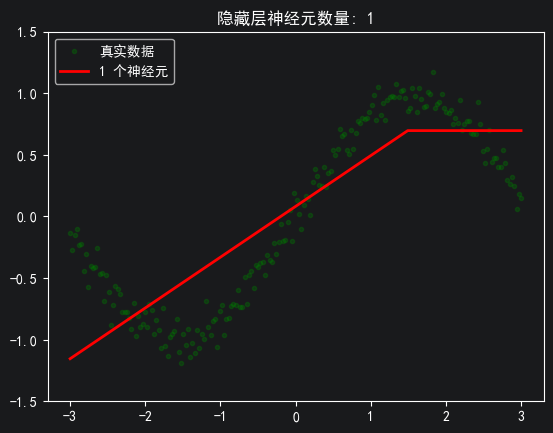

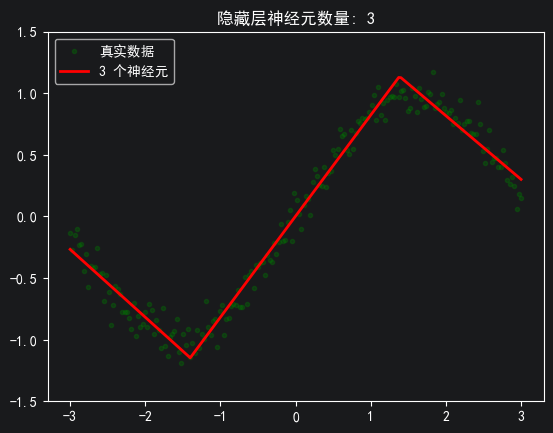

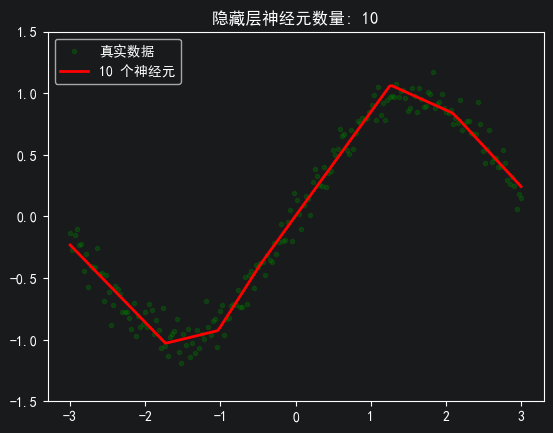

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
# 生成数据：正弦曲线
x = np.linspace(-3, 3, 200).reshape(-1, 1)
y = np.sin(x) + 0.1 * np.random.randn(*x.shape)  # 加一点噪声

# 转为 Tensor
x_t = torch.tensor(x, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# 定义一个简单网络：隐藏层神经元个数可调，激活函数用 ReLU
def fit_with_neurons(n_neurons):
    model = nn.Sequential(
        nn.Linear(1, n_neurons),  # 输入1维，输出 n_neurons 维
        nn.ReLU(),                # 关键：引入非线性
        nn.Linear(n_neurons, 1)   # 输出1维
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    # 训练 2000 步
    for _ in range(2000):
        pred = model(x_t)
        loss = loss_fn(pred, y_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 绘制结果
    with torch.no_grad():
        pred_y = model(x_t).numpy()
    plt.plot(x, y, 'g.', alpha=0.3, label='真实数据')
    plt.plot(x, pred_y, 'r-', linewidth=2, label=f'{n_neurons} 个神经元')
    plt.legend()
    plt.title(f'隐藏层神经元数量: {n_neurons}')
    plt.ylim(-1.5, 1.5)
    plt.show()

# 分别试验 1个、3个、10个 神经元
fit_with_neurons(1)
fit_with_neurons(3)
fit_with_neurons(10)

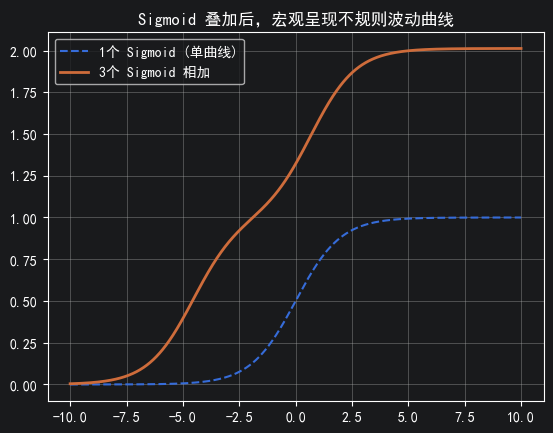

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['sans-serif']

x = np.linspace(-10, 10, 1000)

# 定义激活函数（这里演示 Sigmoid）
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 1个神经元：仅一条 S 曲线
y1 = sigmoid(x)

# 3个神经元：随机调整权重和偏置，然后相加
np.random.seed(42)
w = np.random.randn(3) * 2
b = np.random.randn(3) * 3

y3 = sum(w[i] * sigmoid(x + b[i]) for i in range(3))

plt.plot(x, y1, label='1个 Sigmoid (单曲线)', linestyle='--')
plt.plot(x, y3, label='3个 Sigmoid 相加', linewidth=2)
plt.legend()
plt.title('Sigmoid 叠加后，宏观呈现不规则波动曲线')
plt.grid(True)
plt.show()

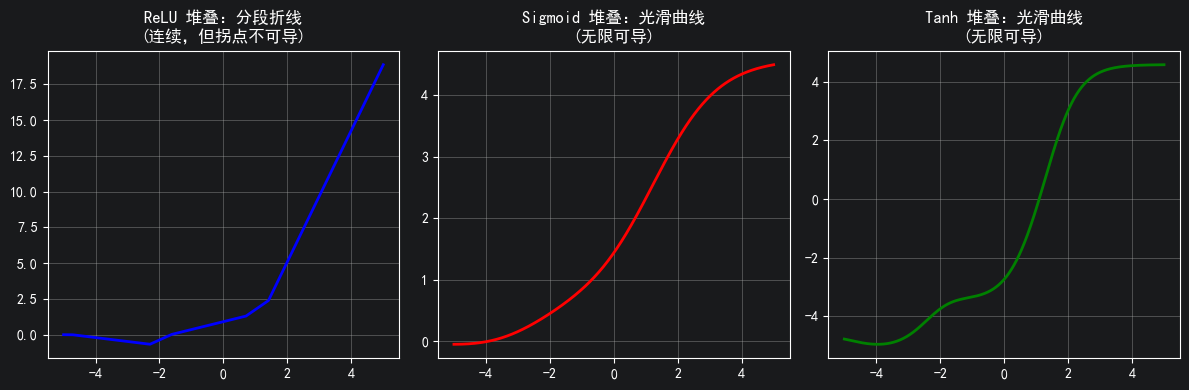

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib
matplotlib.rcParams['font.family'] = ['sans-serif']

# 定义激活函数
def relu(x): return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)

# 生成模拟：单个神经元对这些函数的加权输出
x = np.linspace(-5, 5, 1000)

# 随机生成 5 组参数，模拟多个神经元的叠加
np.random.seed(42)
w = np.random.randn(5) * 2
b = np.random.randn(5) * 3

# 分别计算三种网络的输出（多个激活函数的线性组合）
y_relu = sum(w[i] * relu(x + b[i]) for i in range(5))
y_sigmoid = sum(w[i] * sigmoid(x + b[i]) for i in range(5))
y_tanh = sum(w[i] * tanh(x + b[i]) for i in range(5))

# 绘图对比
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, y_relu, 'b-', linewidth=2)
plt.title('ReLU 堆叠：分段折线\n(连续，但拐点不可导)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, y_sigmoid, 'r-', linewidth=2)
plt.title('Sigmoid 堆叠：光滑曲线\n(无限可导)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, y_tanh, 'g-', linewidth=2)
plt.title('Tanh 堆叠：光滑曲线\n(无限可导)')
plt.grid(True)

plt.tight_layout()
plt.show()